In [2]:
import numpy as np
import pandas as pd

In [34]:
# read all csv files in outputs/allocate_fairness_results_lamb10 and combine them into one dataframe (they all share same columns)
import os
threshold_results_dir = "outputs/allocate_results_1"
threshold_results_files = [f for f in os.listdir(threshold_results_dir) if f.endswith(".csv")]
threshold_results_dfs = [pd.read_csv(os.path.join(threshold_results_dir, f)) for f in threshold_results_files]
threshold_results_df = pd.concat(threshold_results_dfs, ignore_index=True)
# remove rows where 'policy' is 'no action'
threshold_results_df = threshold_results_df[threshold_results_df['policy'] != 'no_action']

In [35]:
threshold_results_df.head()

,policy,allocated_budget,n_users,budget_used,actual_payment_budget_used,mean_y_policy,mean_y_no_action,mean_y_all_action,success_rate_policy,success_rate_no_action,...,group_A_selection_rate,group_A_actual_payment_budget_used,group_A_mean_y_policy,group_A_success_rate_policy,group_B_n,group_B_selected,group_B_selection_rate,group_B_actual_payment_budget_used,group_B_mean_y_policy,group_B_success_rate_policy
0,pto,7.0,1500.0,11.0,2.633333,0.652378,0.652067,0.648556,0.570667,0.570667,...,0.010730,2.000000,0.665093,0.603004,568.0,1.0,0.001761,0.633333,0.631514,0.517606
1,dfl,7.0,1500.0,7.0,2.766667,0.652222,0.652067,0.648556,0.571333,0.570667,...,0.004292,2.166667,0.664914,0.604077,568.0,3.0,0.005282,0.600000,0.631397,0.517606
2,rs,7.0,1500.0,7.0,2.733333,0.652222,0.652067,0.648556,0.571333,0.570667,...,0.004292,2.133333,0.664914,0.604077,568.0,3.0,0.005282,0.600000,0.631397,0.517606
3,pgf,7.0,1500.0,7.0,1.966667,0.652356,0.652067,0.648556,0.572000,0.570667,...,0.005365,1.966667,0.665021,0.605150,568.0,2.0,0.003521,0.000000,0.631573,0.517606
4,pgb,7.0,1500.0,7.0,0.766667,0.651778,0.652067,0.648556,0.570000,0.570667,...,0.002146,0.766667,0.664378,0.601931,568.0,5.0,0.008803,0.000000,0.631103,0.517606


In [7]:
key_cols = ["policy", "budget_used", "true_gain_step_selected"]

# group by BOTH policy and budget_used
key_results_df = (
    threshold_results_df[key_cols]
    .groupby(["policy", "budget_used"])
    .agg({
        "true_gain_step_selected": ["mean", "std"]
    })
    .reset_index()
)

# flatten multi-index columns
key_results_df.columns = [
    "policy",
    "budget_used",
    "true_gain_step_selected_mean",
    "true_gain_step_selected_std",
]

# create "mean ± std" column
key_results_df["True Gain Step Selected"] = (
    key_results_df["true_gain_step_selected_mean"].round(3).astype(str)
    + " ± "
    + key_results_df["true_gain_step_selected_std"].round(3).astype(str)
)

# optional rounding
key_results_df["budget_used"] = key_results_df["budget_used"].round(3)

# keep clean columns
key_results_df = key_results_df[
    ["policy", "budget_used", "True Gain Step Selected"]
]

key_results_df = key_results_df.rename(columns={
    "policy": "Policy",
    "budget_used": "Budget Used",
})

key_results_df

,Policy,Budget Used,True Gain Step Selected
0,dfl,7.0,0.8 ± 0.789
1,dfl,15.0,2.4 ± 2.011
2,dfl,75.0,7.7 ± 3.433
3,dfl,150.0,5.4 ± 6.186
4,oracle,7.0,7.0 ± 0.0
5,oracle,15.0,15.0 ± 0.0
6,oracle,75.0,75.0 ± 0.0
7,oracle,150.0,150.0 ± 0.0
8,pgb,7.0,-0.2 ± 1.135
9,pgb,15.0,-0.3 ± 1.767


In [36]:
key_cols = ["policy", "allocated_budget", "true_gain_step_selected"]

# aggregate mean/std
agg_df = (
    threshold_results_df[key_cols]
    .groupby(["policy", "allocated_budget"])
    .agg({
        "true_gain_step_selected": ["mean", "std"]
    })
    .reset_index()
)

# flatten columns
agg_df.columns = [
    "policy",
    "allocated_budget",
    "mean",
    "std",
]

# create formatted string
agg_df["formatted"] = (
    agg_df["mean"].round(3).map("{:.1f}".format)
    + r" $\pm$ "
    + agg_df["std"].round(3).map("{:.1f}".format)
)

# pivot budgets into columns
latex_df = agg_df.pivot(
    index="policy",
    columns="allocated_budget",
    values="formatted"
).reset_index()

# rename columns
latex_df.columns = [
    "Policy"
] + [
    f"True Gain ({int(col)})"
    for col in latex_df.columns[1:]
]

# generate latex
latex_code = latex_df.to_latex(
    index=False,
    escape=False,   # keep \pm
    column_format="l" + "c" * (len(latex_df.columns) - 1)
)

print(latex_code)

\begin{tabular}{lcccc}
\toprule
Policy & True Gain (7) & True Gain (15) & True Gain (75) & True Gain (150) \\
\midrule
dfl & 1.0 $\pm$ 0.5 & 1.1 $\pm$ 0.7 & -0.5 $\pm$ 1.7 & 0.6 $\pm$ 3.2 \\
oracle & 7.0 $\pm$ 0.0 & 15.0 $\pm$ 0.0 & 75.0 $\pm$ 0.0 & 150.0 $\pm$ 0.0 \\
pgb & -1.0 $\pm$ 0.0 & -1.0 $\pm$ 0.0 & -1.0 $\pm$ 0.0 & -1.0 $\pm$ 0.0 \\
pgc & 0.0 $\pm$ 0.0 & 0.0 $\pm$ 0.0 & 2.0 $\pm$ 0.0 & -4.0 $\pm$ 0.0 \\
pgf & 2.0 $\pm$ 0.0 & 0.0 $\pm$ 0.0 & 0.0 $\pm$ 0.0 & 0.0 $\pm$ 0.0 \\
pto & 0.0 $\pm$ 2.5 & 1.0 $\pm$ 3.6 & -0.2 $\pm$ 3.3 & -0.2 $\pm$ 3.3 \\
random & -1.0 $\pm$ 0.0 & 0.0 $\pm$ 0.0 & -9.0 $\pm$ 0.0 & 3.0 $\pm$ 0.0 \\
rs & 1.0 $\pm$ 0.0 & 1.0 $\pm$ 0.0 & -3.0 $\pm$ 0.0 & 2.0 $\pm$ 0.0 \\
\bottomrule
\end{tabular}



In [25]:
fairness_results_df = threshold_results_df[['policy', 'budget_used', 'true_gain_step_selected', 'group_A_success_rate_policy', 'group_B_success_rate_policy']]
fairness_results_df['success_rate_diff'] = (fairness_results_df['group_A_success_rate_policy'] - fairness_results_df['group_B_success_rate_policy']).abs()
# remove rows where 'policy' is 'oracle'
fairness_results_df = fairness_results_df[fairness_results_df['policy'] != 'oracle']
# remove rows where 'policy' is 'random;
fairness_results_df = fairness_results_df[fairness_results_df['policy'] != 'random']
fairness_results_df.head()

,policy,budget_used,true_gain_step_selected,group_A_success_rate_policy,group_B_success_rate_policy,success_rate_diff
0,pto,7.0,2.0,0.603004,0.521127,0.081878
1,dfl,7.0,1.0,0.604077,0.517606,0.086472
2,rs,7.0,1.0,0.604077,0.517606,0.086472
3,pgf,7.0,1.0,0.603004,0.519366,0.083638
4,pgb,7.0,-1.0,0.601931,0.517606,0.084326


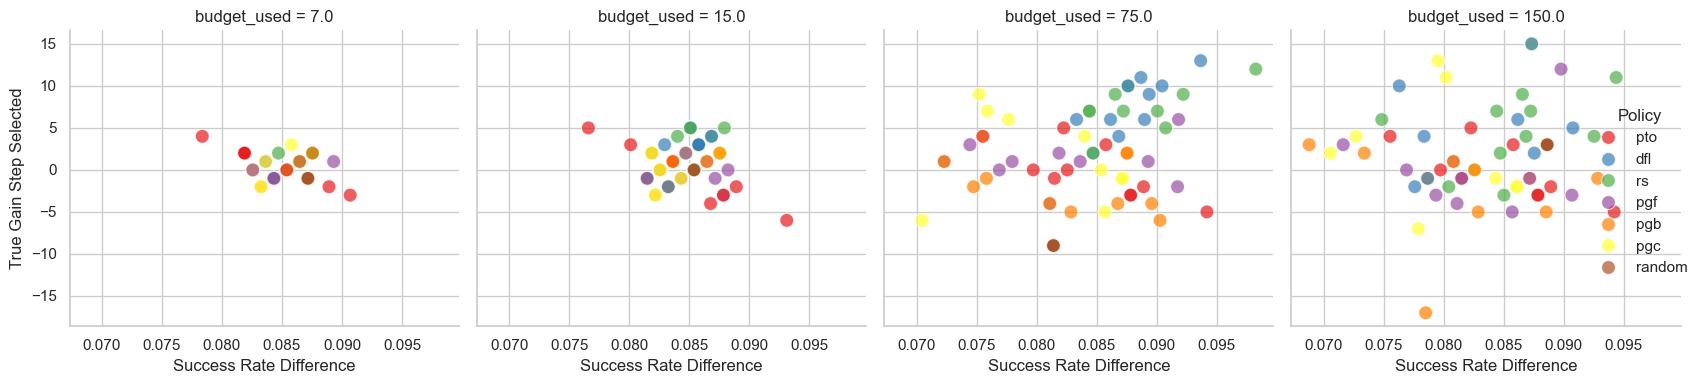

In [21]:
# make a scatter plot with x axis as 'success_rate_diff' and y axis as 'true_gain_step_selected', color by 'policy'. 
# make one plot for each budget_used (facet by budget_used)
import seaborn as sns
import matplotlib.pyplot as plt

sns.set(style="whitegrid")
g = sns.FacetGrid(fairness_results_df, col="budget_used", height=4, aspect=1)
g.map_dataframe(
    sns.scatterplot,
    x="success_rate_diff",
    y="true_gain_step_selected",
    hue="policy",
    palette="Set1",
    alpha=0.7,
    edgecolor="w",
    s=100
)
g.set_axis_labels("Success Rate Difference", "True Gain Step Selected")
g.add_legend(title="Policy")
plt.tight_layout()
plt.show()

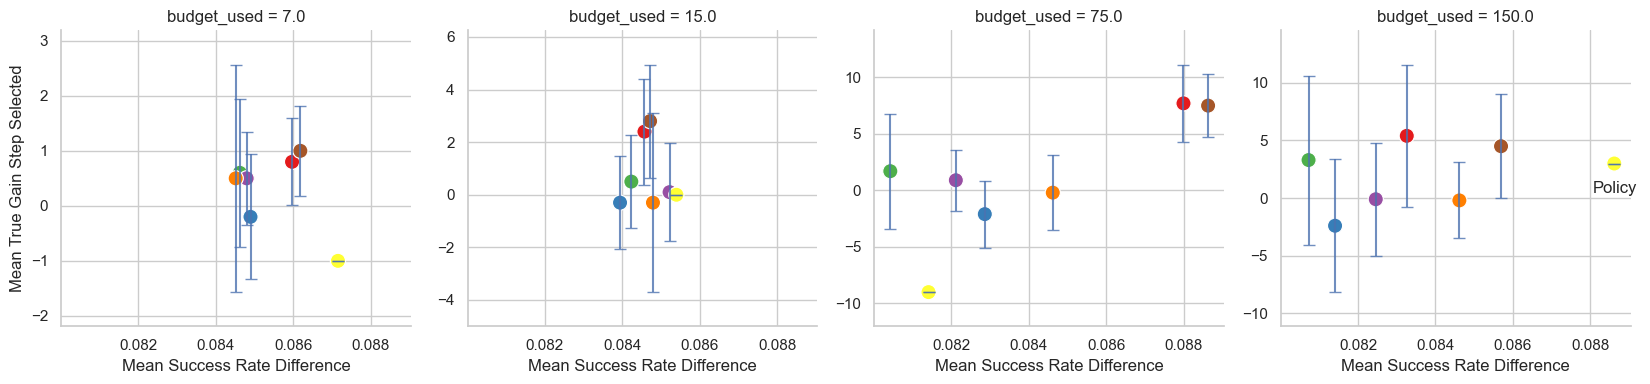

In [23]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.set(style="whitegrid")

plot_df = (
    fairness_results_df
    .groupby(["budget_used", "policy"])
    .agg(
        mean_success_rate_diff=("success_rate_diff", "mean"),
        mean_true_gain=("true_gain_step_selected", "mean"),
        std_true_gain=("true_gain_step_selected", "std"),
    )
    .reset_index()
)

g = sns.FacetGrid(
    plot_df,
    col="budget_used",
    height=4,
    aspect=1,
    sharey=False   # <-- different y-axis range per panel
)

def mean_errorbar(data, **kwargs):
    ax = plt.gca()

    sns.scatterplot(
        data=data,
        x="mean_success_rate_diff",
        y="mean_true_gain",
        hue="policy",
        palette="Set1",
        s=120,
        edgecolor="w",
        ax=ax,
        legend=False,
    )

    for _, row in data.iterrows():
        ax.errorbar(
            x=row["mean_success_rate_diff"],
            y=row["mean_true_gain"],
            yerr=row["std_true_gain"],
            fmt="none",
            capsize=4,
            alpha=0.8,
        )

    # optional padding so points aren't touching borders
    ymin = (data["mean_true_gain"] - data["std_true_gain"]).min()
    ymax = (data["mean_true_gain"] + data["std_true_gain"]).max()
    padding = 0.15 * (ymax - ymin + 1e-6)

    ax.set_ylim(ymin - padding, ymax + padding)

g.map_dataframe(mean_errorbar)

g.set_axis_labels(
    "Mean Success Rate Difference",
    "Mean True Gain Step Selected"
)

g.add_legend(title="Policy")

plt.tight_layout()
plt.show()

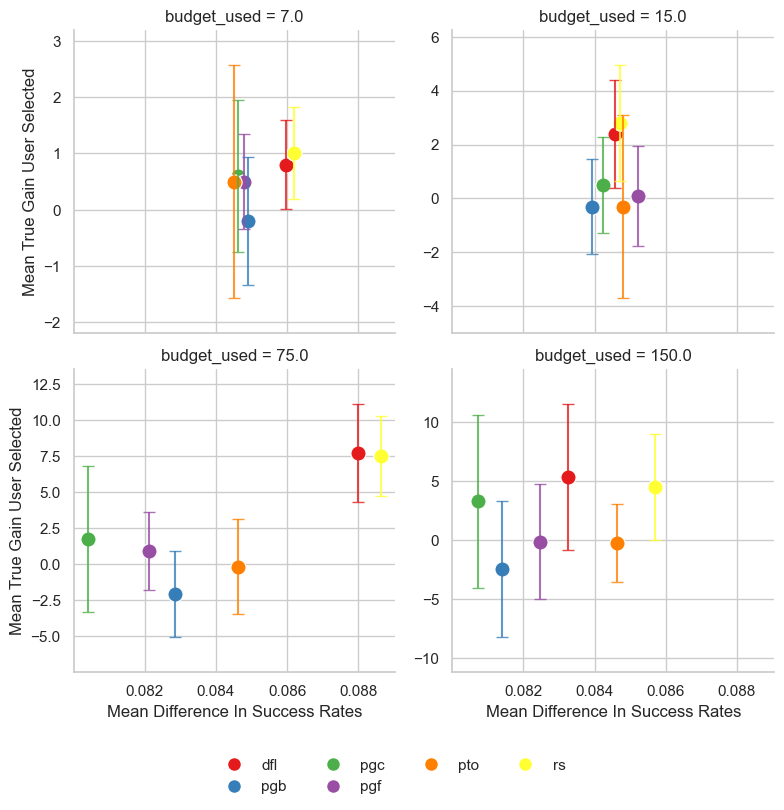

In [29]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.set(style="whitegrid")

plot_df = (
    fairness_results_df
    .groupby(["budget_used", "policy"])
    .agg(
        mean_success_rate_diff=("success_rate_diff", "mean"),
        mean_true_gain=("true_gain_step_selected", "mean"),
        std_true_gain=("true_gain_step_selected", "std"),
    )
    .reset_index()
)

# consistent colors
policies = sorted(plot_df["policy"].unique())
palette = dict(zip(policies, sns.color_palette("Set1", n_colors=len(policies))))

g = sns.FacetGrid(
    plot_df,
    col="budget_used",
    col_wrap=2,          # <-- 2x2 layout
    height=4,
    aspect=1,
    sharey=False
)

def mean_errorbar(data, **kwargs):
    ax = plt.gca()

    # plot each policy separately so legend works
    for policy in policies:
        sub = data[data["policy"] == policy]

        sns.scatterplot(
            data=sub,
            x="mean_success_rate_diff",
            y="mean_true_gain",
            color=palette[policy],
            s=120,
            edgecolor="w",
            label=policy,
            ax=ax,
        )

        for _, row in sub.iterrows():
            ax.errorbar(
                x=row["mean_success_rate_diff"],
                y=row["mean_true_gain"],
                yerr=row["std_true_gain"],
                fmt="none",
                color=palette[policy],
                capsize=4,
                alpha=0.8,
            )

    # adaptive y-axis
    ymin = (data["mean_true_gain"] - data["std_true_gain"]).min()
    ymax = (data["mean_true_gain"] + data["std_true_gain"]).max()
    padding = 0.15 * (ymax - ymin + 1e-6)

    ax.set_ylim(ymin - padding, ymax + padding)

g.map_dataframe(mean_errorbar)

g.set_axis_labels(
    "Mean Difference In Success Rates",
    "Mean True Gain User Selected"
)

# single legend at bottom
g.fig.legend(
    handles=[
        plt.Line2D(
            [0], [0],
            marker='o',
            color='w',
            markerfacecolor=palette[p],
            markersize=10,
            label=p
        )
        for p in policies
    ],
    labels=policies,
    loc="lower center",
    bbox_to_anchor=(0.5, -0.02),
    ncol=min(4, len(policies)),
    frameon=False
)

plt.tight_layout()
plt.subplots_adjust(bottom=0.15)  # space for legend
# save figure
plt.savefig("fairness_vs_gain_rank.png", dpi=300, bbox_inches="tight")
